In [22]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

In [23]:
class PrivateState(TypedDict):
    a: int
    b: int

class InputState(TypedDict):
    hello: str

class OutputState(TypedDict):
    bye: str

class MegaPrivateState(TypedDict):
    secret : bool
graph_builder = StateGraph(
    PrivateState,
    input_schema=InputState,
    output_schema=OutputState
)

In [24]:
def node_one(state: InputState) -> InputState:
    print("node_one", state)
    return { "hello": "world" }

def node_two(state: PrivateState) -> PrivateState:
    print("node_two", state)
    return { "a": 1 }

def node_three(state: PrivateState) -> PrivateState:
    print("node_three", state)
    return { "b": 2 }

def node_four(state: PrivateState) -> OutputState:
    print("node_four", state)
    return { "bye": "bye" }

def node_five(state: OutputState):
    print("node_five", state)
    return { "secret": True }

def node_six(state: MegaPrivateState):
    print("node_six", state)

In [25]:
graph_builder.add_node("node_one",node_one)
graph_builder.add_node("node_two",node_two)
graph_builder.add_node("node_three",node_three)
graph_builder.add_node("node_four",node_four)
graph_builder.add_node("node_five",node_five)
graph_builder.add_node("node_six",node_six)

graph_builder.add_edge(START,"node_one")
graph_builder.add_edge("node_one","node_two")
graph_builder.add_edge("node_two","node_three")
graph_builder.add_edge("node_three","node_four")
graph_builder.add_edge("node_four","node_five")
graph_builder.add_edge("node_five","node_six")
graph_builder.add_edge("node_six",END)

In [27]:
graph = graph_builder.compile()

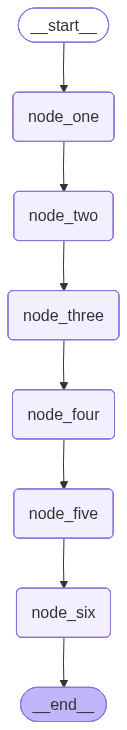

In [28]:
graph


In [29]:
result = graph.invoke({"hello":"world"})
print(result)

node_one {'hello': 'world'}
node_two {}
node_three {'a': 1}
node_four {'a': 1, 'b': 2}
node_five {'bye': 'bye'}
node_six {'secret': True}
{'bye': 'bye'}
